현재 위치: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\US_Market\analysis\FS_Data_Analysis\fs_basic_analysis\basic_analysis
✓ 프로젝트 루트 추가: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
✓ 모든 모듈 import 완료!


✓ DB 설정 완료
  Host: 192.168.0.230:3307

분석 대상: STRL Inc. (STRL)
Indicator: revenue_billions_sarima_noexog
Forecast Date: 2026-01-03

[1/5] Historical 재무 데이터 수집 중...
  ✓ Revenue: 23 rows
  ✓ Operating Income: 23 rows
  ✓ Net Income: 23 rows

[2/5] 데이터 정리 및 병합 중...
  rev dup: 0, op dup: 0, ni dup: 0
  ✓ 병합 완료: 23 rows

[3/5] 회귀 모델 구축 중...
  회귀식: OI = 0.2515 × Revenue + -0.69
  R² = 0.8118

[4/5] DB에서 매출 예측 데이터 로드...
✓ DB 연결 성공: 192.168.0.230:3307/investar
  ✓ 매출 예측 데이터 로드 완료: 5개 분기
  기간: 2026-03-31 ~ 2027-03-31

[5/5] 영업이익 예측 중...
  ✓ 영업이익 예측 완료: 5개 분기


예측 결과:
      date ticker  revenue_forecast_billions  revenue_forecast_1e8  op_income_pred_1e8  op_income_pred_usd  op_income_pred_billions
2026-03-31   STRL                   0.544579              5.445793    

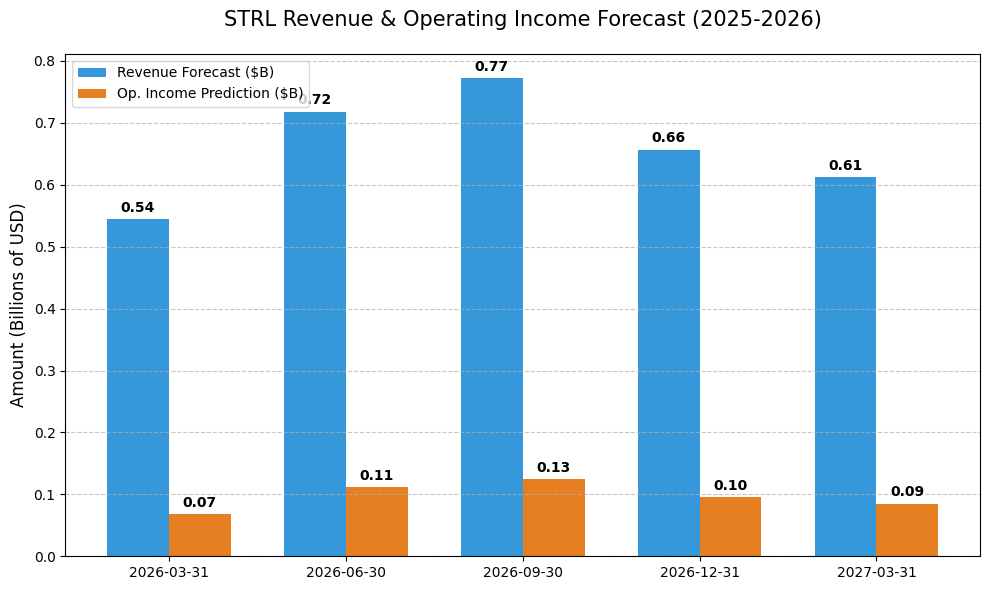


회귀 분석 차트 생성 중...
✓ 회귀 분석 차트 저장 완료: ./revenue_oi_charts/STRL/STRL_regression_analysis.png


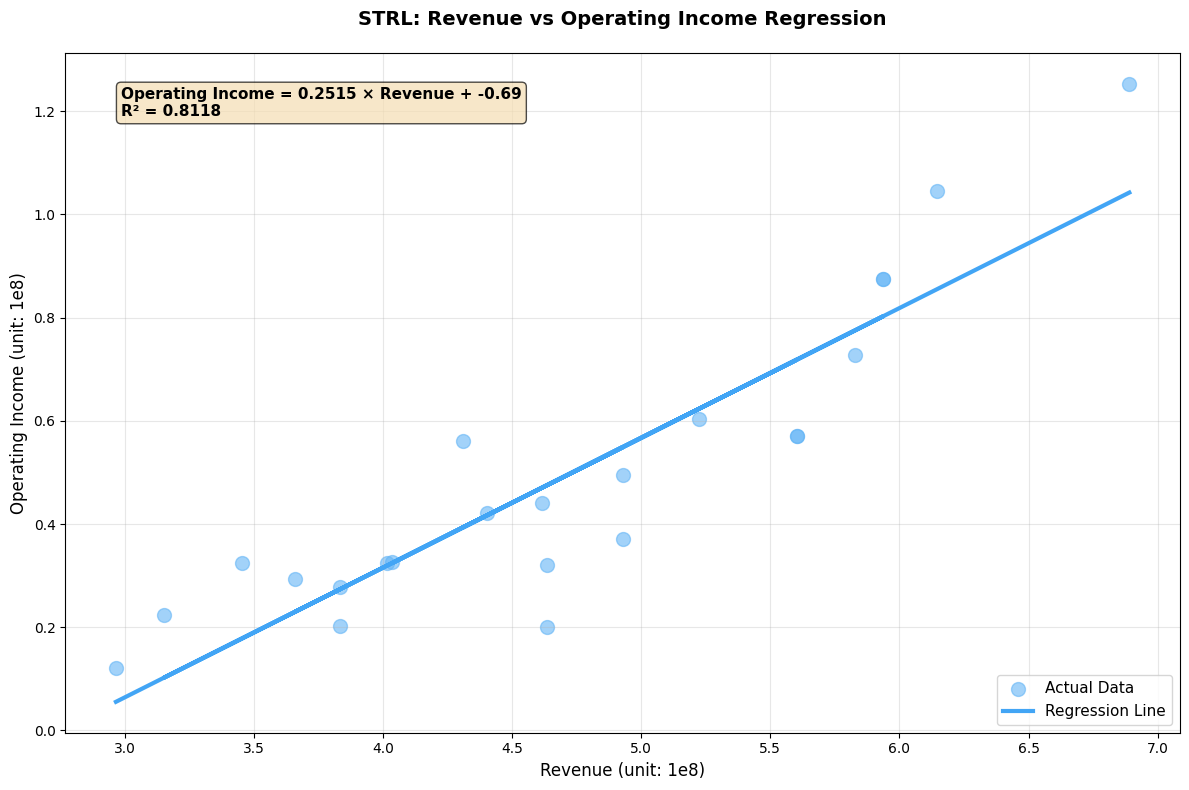


Excel 파일 저장 중...
✓ Excel 저장 완료: ./revenue_oi_charts/STRL/STRL_forecast_results.xlsx

✓ 모든 작업 완료!

저장 위치: ./revenue_oi_charts/STRL/

생성된 파일:
  1. STRL_forecast_hoyoung_style.png    - 예측 차트
  2. STRL_regression_analysis.png       - 회귀 분석 차트
  3. STRL_forecast_results.xlsx         - 예측 결과 Excel

실행 완료!


In [2]:
# ============================================================================
# Revenue & Operating Income Forecaster - 호영님 데이터 추출 방식 완전 반영
# ============================================================================

import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymysql
from typing import Dict, List, Optional
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sqlalchemy import create_engine, text

# ============================================================================
# 1. 프로젝트 경로 설정
# ============================================================================

def setup_investment_strategy_path():
    """investment_strategy 프로젝트 루트를 sys.path에 추가"""
    current = Path.cwd()
    print(f"현재 위치: {current}")

    for parent in [current] + list(current.parents):
        if parent.name == 'investment_strategy':
            project_root = str(parent)
            if project_root not in sys.path:
                sys.path.insert(0, project_root)
            print(f"✓ 프로젝트 루트 추가: {project_root}")
            return project_root

    fallback = r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy"
    if os.path.exists(fallback):
        if fallback not in sys.path:
            sys.path.insert(0, fallback)
        print(f"✓ Fallback 경로 사용: {fallback}")
        return fallback

    raise FileNotFoundError("investment_strategy 폴더를 찾을 수 없습니다.")

project_root = setup_investment_strategy_path()


# ============================================================================
# 2. Import
# ============================================================================

from DATA.stock_invest_function import get_db_host

print("✓ 모든 모듈 import 완료!")
print("=" * 70 + "\n")


# ============================================================================
# 3. RevenueForecastViewer 클래스 정의 (호영님 코드)
# ============================================================================

class RevenueForecastViewer:
    """Revenue Forecast 데이터 조회 클래스"""

    def __init__(self, db_config):
        self.db_config = db_config
        self.engine = None
        self._connect_db()

    def _connect_db(self):
        """DB 연결"""
        try:
            conn_str = (
                f"mysql+pymysql://{self.db_config['user']}:{self.db_config['password']}@"
                f"{self.db_config['host']}:{self.db_config['port']}/"
                f"{self.db_config['database']}?charset=utf8mb4"
            )
            self.engine = create_engine(conn_str)
            print(f"✓ DB 연결 성공: {self.db_config['host']}:{self.db_config['port']}/{self.db_config['database']}")
        except Exception as e:
            print(f"✗ DB 연결 실패: {e}")
            raise

    def query_revenue_forecast(self, ticker, forecast_date, indicator=None):
        """Revenue forecast 데이터 조회"""
        conditions = ["ticker = :ticker", "forecast_date = :forecast_date"]
        params = {'ticker': ticker, 'forecast_date': forecast_date}

        if indicator:
            conditions.append("indicator = :indicator")
            params['indicator'] = indicator

        where_clause = " AND ".join(conditions)

        query = f"""
        SELECT
            date,
            ticker,
            indicator,
            value,
            forecast_date,
            created_at,
            updated_at
        FROM us_revenue_forecast_result
        WHERE {where_clause}
        ORDER BY date, indicator
        """

        try:
            with self.engine.connect() as conn:
                df = pd.read_sql(text(query), conn, params=params)

            if df.empty:
                print(f"⚠ 조회된 데이터가 없습니다.")
                return df

            df['date'] = pd.to_datetime(df['date'])
            df['forecast_date'] = pd.to_datetime(df['forecast_date'])

            return df

        except Exception as e:
            print(f"✗ 데이터 조회 실패: {e}")
            return pd.DataFrame()


# ============================================================================
# 4. fetch_sec_financial_item_pivot 함수 정의 (호영님 코드)
# ============================================================================

def fetch_sec_financial_item_pivot(
    db_info: Dict,
    item_name: str,
    table_name: str = "sec_financial_data",
    tickers: Optional[List[str]] = None,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None
) -> pd.DataFrame:
    """sec_financial_data 테이블에서 데이터 조회"""

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        where_clauses = ["item_name = %s"]
        params: List = [item_name]

        if tickers:
            placeholders = ", ".join(["%s"] * len(tickers))
            where_clauses.append(f"ticker IN ({placeholders})")
            params.extend(tickers)

        if start_date:
            where_clauses.append("date >= %s")
            params.append(start_date)

        if end_date:
            where_clauses.append("date <= %s")
            params.append(end_date)

        where_sql = "WHERE " + " AND ".join(where_clauses)

        query = f"""
            SELECT
                date,
                ticker,
                value
            FROM {table_name}
            {where_sql}
            ORDER BY date, ticker;
        """

        df = pd.read_sql(query, conn, params=params)

    finally:
        conn.close()

    if df.empty:
        print(f"[WARN] No data for item_name={item_name}, tickers={tickers}")
        return df

    df["date"] = pd.to_datetime(df["date"])
    df = df.rename(columns={"value": item_name})
    df = df[["date", "ticker", item_name]]

    return df


# ============================================================================
# 5. _prep_one_per_date 함수 정의 (호영님 코드)
# ============================================================================

def _prep_one_per_date(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """date 기준 중복 제거 및 정리"""
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = out.dropna(subset=["date"])
    out = out.sort_values("date").drop_duplicates(subset=["date"], keep="last")
    return out[["date", value_col]].reset_index(drop=True)


# ============================================================================
# 6. DB 설정
# ============================================================================

db_config = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}

print("\n✓ DB 설정 완료")
print(f"  Host: {db_config['host']}:{db_config['port']}\n")


# ============================================================================
# 7. 분석할 종목 설정
# ============================================================================

TICKER = "STRL"
COMPANY_NAME = "STRL Inc."
TARGET_INDICATOR = "revenue_billions_sarima_noexog"
FORECAST_DATE = '2026-01-03'

print(f"분석 대상: {COMPANY_NAME} ({TICKER})")
print(f"Indicator: {TARGET_INDICATOR}")
print(f"Forecast Date: {FORECAST_DATE}")
print("=" * 70 + "\n")


# ============================================================================
# 8. Historical 재무 데이터 수집 (호영님 방식)
# ============================================================================

print("[1/5] Historical 재무 데이터 수집 중...")

tickers = [TICKER]

# Revenue, Operating Income, Net Income 조회
rev_df = fetch_sec_financial_item_pivot(
    db_info=db_config,
    item_name="revenue",
    tickers=tickers,
    start_date="2020-01-01"
)

op_df = fetch_sec_financial_item_pivot(
    db_info=db_config,
    item_name="operating_income",
    tickers=tickers,
    start_date="2020-01-01"
)

ni_df = fetch_sec_financial_item_pivot(
    db_info=db_config,
    item_name="net_income",
    tickers=tickers,
    start_date="2020-01-01"
)

print(f"  ✓ Revenue: {len(rev_df)} rows")
print(f"  ✓ Operating Income: {len(op_df)} rows")
print(f"  ✓ Net Income: {len(ni_df)} rows\n")


# ============================================================================
# 9. 데이터 정리 및 병합 (호영님 방식)
# ============================================================================

print("[2/5] 데이터 정리 및 병합 중...")

rev_1 = _prep_one_per_date(rev_df, "revenue")
op_1 = _prep_one_per_date(op_df, "operating_income")
ni_1 = _prep_one_per_date(ni_df, "net_income")

# 중복 체크
print(f"  rev dup: {rev_1['date'].duplicated().sum()}, "
      f"op dup: {op_1['date'].duplicated().sum()}, "
      f"ni dup: {ni_1['date'].duplicated().sum()}")

# Merge (1:1 검증)
reg = pd.merge(rev_1, op_1, on="date", how="left", validate="one_to_one")
reg = pd.merge(reg, ni_1, on="date", how="left", validate="one_to_one")

# 단위 변환: USD → 1e8
reg[["revenue", "operating_income", "net_income"]] = reg[["revenue", "operating_income", "net_income"]] / 100000000

# NaN 제거
reg = reg.dropna(subset=["revenue", "operating_income"]).copy()

print(f"  ✓ 병합 완료: {len(reg)} rows\n")


# ============================================================================
# 10. 회귀 모델 구축 (호영님 방식)
# ============================================================================

print("[3/5] 회귀 모델 구축 중...")

X = reg["revenue"].values.reshape(-1, 1)
y = reg["operating_income"].values

model = LinearRegression()
model.fit(X, y)

slope = float(model.coef_[0])
intercept = float(model.intercept_)
y_pred = model.predict(X)
r_squared = r2_score(y, y_pred)

print(f"  회귀식: OI = {slope:.4f} × Revenue + {intercept:.2f}")
print(f"  R² = {r_squared:.4f}\n")


# ============================================================================
# 11. DB에서 매출 예측 데이터 로드 (호영님 방식)
# ============================================================================

print("[4/5] DB에서 매출 예측 데이터 로드...")

viewer = RevenueForecastViewer(db_config)

# 데이터 조회
df = viewer.query_revenue_forecast(TICKER, FORECAST_DATE)

if df.empty:
    print("✗ 매출 예측 데이터가 없습니다.")
    sys.exit(1)

# 특정 indicator만 필터링 후 마지막 5개 분기
forecasted_revenue = df[df['indicator'] == TARGET_INDICATOR].tail(5).copy()

print(f"  ✓ 매출 예측 데이터 로드 완료: {len(forecasted_revenue)}개 분기")
print(f"  기간: {forecasted_revenue['date'].iloc[0].strftime('%Y-%m-%d')} ~ {forecasted_revenue['date'].iloc[-1].strftime('%Y-%m-%d')}\n")


# ============================================================================
# 12. 영업이익 예측 (호영님 방식)
# ============================================================================

print("[5/5] 영업이익 예측 중...")

# 단위 변환: billions → 1e8
forecasted_revenue["revenue_billions"] = forecasted_revenue["value"].astype(float)
forecasted_revenue["revenue_in_1e8"] = forecasted_revenue["revenue_billions"] * 10.0

# 회귀식으로 예측
X_future = forecasted_revenue["revenue_in_1e8"].values.reshape(-1, 1)
op_pred_1e8 = model.predict(X_future)

# 결과 정리
df_pred = pd.DataFrame({
    "date": forecasted_revenue["date"].dt.strftime("%Y-%m-%d").values,
    "ticker": forecasted_revenue["ticker"].values,
    "revenue_forecast_billions": forecasted_revenue["revenue_billions"].values,
    "revenue_forecast_1e8": forecasted_revenue["revenue_in_1e8"].values,
    "op_income_pred_1e8": op_pred_1e8,
    "op_income_pred_usd": op_pred_1e8 * 100000000,
    "op_income_pred_billions": (op_pred_1e8 * 100000000) / 1e9,
})

df_pred['date'] = pd.to_datetime(df_pred['date'])
df_pred = df_pred.sort_values('date')

print(f"  ✓ 영업이익 예측 완료: {len(df_pred)}개 분기\n")

print("\n예측 결과:")
print(df_pred.to_string(index=False))
print()


# ============================================================================
# 13. 시각화 (호영님 코드 그대로)
# ============================================================================

print("\n" + "=" * 70)
print("시각화 생성 중...")
print("=" * 70)

forecast_data = df_pred.copy()
forecast_data['revenue_bn'] = forecast_data['revenue_forecast_billions']
forecast_data['op_income_bn'] = forecast_data['op_income_pred_billions']

# 시각화 설정
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = range(len(forecast_data))

# 막대 그래프
bar1 = ax.bar([i - bar_width/2 for i in index], forecast_data['revenue_bn'],
              bar_width, label='Revenue Forecast ($B)', color='#3498db')
bar2 = ax.bar([i + bar_width/2 for i in index], forecast_data['op_income_bn'],
              bar_width, label='Op. Income Prediction ($B)', color='#e67e22')

# 막대 위에 수치 표시
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

add_labels(bar1)
add_labels(bar2)

# 그래프 꾸미기
ax.set_title(f'{TICKER} Revenue & Operating Income Forecast (2025-2026)',
             fontsize=15, pad=20)
ax.set_ylabel('Amount (Billions of USD)', fontsize=12)
ax.set_xticks(index)
ax.set_xticklabels(forecast_data['date'].dt.strftime('%Y-%m-%d'), rotation=0)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# 저장
save_dir = f'./revenue_oi_charts/{TICKER}'
os.makedirs(save_dir, exist_ok=True)
save_path = f"{save_dir}/{TICKER}_forecast_hoyoung_style.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✓ 차트 저장 완료: {save_path}")

plt.show()


# ============================================================================
# 14. 회귀 분석 차트 (추가)
# ============================================================================

print("\n회귀 분석 차트 생성 중...")

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
ax.scatter(X, y, alpha=0.6, s=100, label='Actual Data', color='#64B5F6')

# Regression line
ax.plot(X, y_pred, 'r-', linewidth=3, label='Regression Line', color='#42A5F5')

# 회귀식 표시
equation_text = (
    f'Operating Income = {slope:.4f} × Revenue + {intercept:.2f}\n'
    f'R² = {r_squared:.4f}'
)

ax.text(0.05, 0.95, equation_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax.set_title(f'{TICKER}: Revenue vs Operating Income Regression',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Revenue (unit: 1e8)', fontsize=12)
ax.set_ylabel('Operating Income (unit: 1e8)', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
regression_path = f"{save_dir}/{TICKER}_regression_analysis.png"
plt.savefig(regression_path, dpi=300, bbox_inches='tight')
print(f"✓ 회귀 분석 차트 저장 완료: {regression_path}")

plt.show()


# ============================================================================
# 15. Excel 저장
# ============================================================================

print("\nExcel 파일 저장 중...")

try:
    excel_path = f"{save_dir}/{TICKER}_forecast_results.xlsx"

    export_df = df_pred[[
        'date', 'ticker',
        'revenue_forecast_billions',
        'op_income_pred_billions'
    ]].copy()

    export_df.columns = [
        'Date', 'Ticker',
        'Revenue Forecast ($B)',
        'Operating Income Forecast ($B)'
    ]

    # 회귀 모델 정보도 함께 저장
    with pd.ExcelWriter(excel_path) as writer:
        export_df.to_excel(writer, sheet_name='Forecast', index=False)

        # 회귀 모델 정보 시트
        model_info = pd.DataFrame({
            'Metric': ['Slope', 'Intercept', 'R²'],
            'Value': [slope, intercept, r_squared]
        })
        model_info.to_excel(writer, sheet_name='Regression Model', index=False)

    print(f"✓ Excel 저장 완료: {excel_path}")

except Exception as e:
    print(f"✗ Excel 저장 실패: {e}")


# ============================================================================
# 16. 결과 요약
# ============================================================================

print("\n" + "=" * 70)
print("✓ 모든 작업 완료!")
print("=" * 70)

print(f"\n저장 위치: {save_dir}/")
print("\n생성된 파일:")
print(f"  1. {TICKER}_forecast_hoyoung_style.png    - 예측 차트")
print(f"  2. {TICKER}_regression_analysis.png       - 회귀 분석 차트")
print(f"  3. {TICKER}_forecast_results.xlsx         - 예측 결과 Excel")

print("\n" + "=" * 70)
print("실행 완료!")
print("=" * 70)